In [ ]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# 1. Loading
df = pd.read_csv('cleaned_drug_side_effects.csv')

# Utility function to transform strings "A;B;C" into lists ['A', 'B', 'C']
def split_items(x):
   return x.split(';') if pd.notnull(x) else []

# Transform the column into a list
df['targets_list'] = df['targets'].apply(split_items)

# MultiLabelBinarizer creates one column per possible target
mlb_targets = MultiLabelBinarizer()
X_targets = mlb_targets.fit_transform(df['targets_list'])
print(f"Shape of 'targets' features: {X_targets.shape}") 
# Expected result: (1052, ~1148)

Shape of 'targets' features: (1052, 1400)


# Encoding Names (Explanatory Variables)
We use TF-IDF on characters (n-grams of size 3 to 5).

Capturing roots like "meth", "oxy", "zole".
analyzer='char': Instead of reading entire words (like "cat", "dog"), the algorithm will read characters (letters).

This is crucial because drug names do not have "sentences", the meaning is hidden within the word itself. ngram_range=(3, 5): This instructs the algorithm to create a sliding window that captures groups of 3, 4, and 5 consecutive letters.

In [ ]:
# Using TF-IDF Vectorizer with character n-grams (3 to 5 letters)
tfidf = TfidfVectorizer(analyzer='char', ngram_range=(3, 5))

# Fit: It scans through the entire drug_name column, splits all names into n-grams (3 to 5 letters) and builds a gigantic dictionary of all existing combinations (e.g., azep, zepa, epam...)
# Transform: It replaces each drug name with a numerical vector (a sequence of numbers)
X_names = tfidf.fit_transform(df['drug_name'])

print(f"Shape of 'names' features: {X_names.shape}")

Shape of 'names' features: (1052, 10205)


In [ ]:
# Transform the column into a list
df['side_effects_list'] = df['side_effect'].apply(split_items)

# MultiLabelBinarizer creates one column per possible side effect
mlb_effects = MultiLabelBinarizer()
y = mlb_effects.fit_transform(df['side_effects_list'])

# Print the shape of the target variable
print(f"Shape of the target 'y': {y.shape}")
# Expected result: (1052, ~5735)

Shape of the target 'y': (1052, 5735)


In [ ]:


# --- D. Fusion for the model ---
# To obtain your final matrix X, concatenate the features
X_final = np.hstack([X_targets, X_names.toarray()])

print(f"Final matrix for training: {X_final.shape}")
print(f"First rows of the final matrix X_final:\n{X_final[:5]}")  # Displays the first 5 rows and 5 columns

Final matrix for training: (1052, 11605)
First rows of the final matrix X_final:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [7]:
from sklearn.model_selection import train_test_split

# Garder uniquement les 50 effets les plus fréquents
top_50_indices = y.sum(axis=0).argsort()[-500:][::-1]
y_filtered = y[:, top_50_indices]

# Séparation Train / Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X_final, y_filtered, test_size=0.2, random_state=42)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (841, 11605)
Test shape: (211, 11605)


## GridSearchCV to find optimized parameter to our baseline model (Logistic Regression)

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, f1_score

# 1. Définir le modèle de base (adapté au multi-label)
# On utilise solver='liblinear' car il gère bien les données creuses et la régularisation L1/L2
base_model = OneVsRestClassifier(LogisticRegression(solver='liblinear', random_state=42))

# 2. Définir la grille d'hyperparamètres
# Notez le préfixe "estimator__" car le modèle est encapsulé dans OneVsRestClassifier
param_grid = {
    'estimator__C': [0.1, 1, 10],            # Force de la régularisation
    'estimator__penalty': ['l1', 'l2']       # Type de régularisation
}

# 3. Configurer le Grid Search
# On optimise le F1-score 'micro' qui est standard pour le multi-label déséquilibré
scorer = make_scorer(f1_score, average='micro')

grid_search = GridSearchCV(base_model, param_grid, cv=3, scoring=scorer, verbose=2, n_jobs=-1)

# 4. Entraîner (Cela peut prendre du temps)
print("Démarrage du Grid Search...")
grid_search.fit(X_train, y_train)

# 5. Résultats
print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur score CV (F1 Micro) : {grid_search.best_score_}")

# Sauvegarder le meilleur modèle
best_baseline = grid_search.best_estimator_

Démarrage du Grid Search...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Meilleurs paramètres : {'estimator__C': 10, 'estimator__penalty': 'l2'}
Meilleur score CV (F1 Micro) : 0.4344293854381638


## Bagging method on RandomForestClassifier

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest gère nativement le multi-output, pas besoin de OneVsRest (souvent plus rapide)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Random Forest entraîné.")

Random Forest entraîné.


## Voting method on 3 models (LogisticRegression, MultinomialNB and RandomForestClassifier)

In [ ]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier

# Définir les classificateurs de base
clf1 = LogisticRegression(solver='liblinear', random_state=1)
clf2 = RandomForestClassifier(n_estimators=50, random_state=1)
clf3 = MultinomialNB()

# Voting 'soft' utilise les probabilités pondérées
voting_clf = OneVsRestClassifier(VotingClassifier(
    estimators=[('lr', clf1), ('rf', clf2), ('nb', clf3)],
    voting='soft'
))

voting_clf.fit(X_train, y_train)
print("Voting Classifier entraîné.")

Voting Classifier entraîné.


## Evaluation

--- Performance : Baseline Optimized ---
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       188
           1       0.83      0.97      0.90       174
           2       0.81      0.92      0.86       172
           3       0.81      0.93      0.87       173
           4       0.82      0.93      0.87       166
           5       0.80      0.91      0.85       163
           6       0.81      0.83      0.82       163
           7       0.73      0.88      0.80       148
           8       0.78      0.87      0.82       150
           9       0.64      0.82      0.72       133
          10       0.67      0.73      0.70       135
          11       0.66      0.81      0.73       127
          12       0.66      0.73      0.69       128
          13       0.66      0.76      0.71       125
          14       0.68      0.69      0.68       127
          15       0.69      0.74      0.71       121
          16       0.62      0.68      0

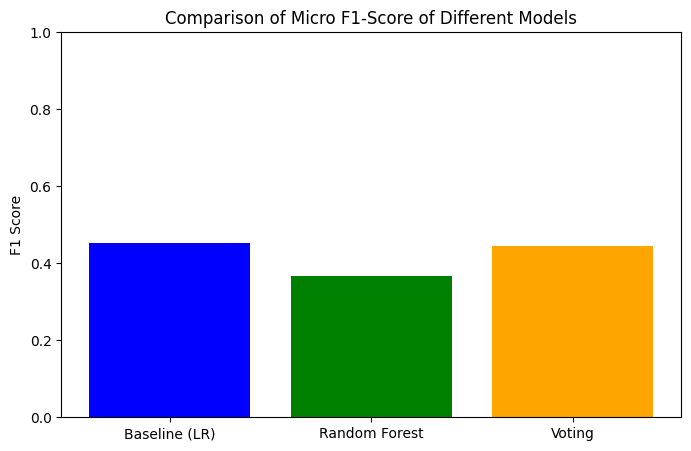

In [ ]:
from sklearn.metrics import classification_report, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    
    # Textual report
    print(f"--- Performance : {model_name} ---")
    print(classification_report(y_test, y_pred, zero_division=0)) # Warning: very long output if 5000 classes
    
    # More concise alternative:
    print(f"F1 Micro: {f1_score(y_test, y_pred, average='micro'):.4f}")
    print(f"F1 Macro: {f1_score(y_test, y_pred, average='macro'):.4f}")
    
    return y_pred

# Comparison
y_pred_baseline = evaluate_model(best_baseline, X_test, y_test, "Baseline Optimized")
y_pred_rf = evaluate_model(rf_model, X_test, y_test, "Random Forest")
y_pred_voting = evaluate_model(voting_clf, X_test, y_test, "Voting Classifier")

# Visualization: Comparison of F1 Scores
models = ['Baseline (LR)', 'Random Forest', 'Voting']
scores = [
    f1_score(y_test, y_pred_baseline, average='micro'),
    f1_score(y_test, y_pred_rf, average='micro'),
    f1_score(y_test, y_pred_voting, average='micro')
]

plt.figure(figsize=(8, 5))
plt.bar(models, scores, color=['blue', 'green', 'orange'])
plt.title('Comparison of Micro F1-Score of Different Models')
plt.ylim(0, 1)
plt.ylabel('F1 Score')
plt.savefig('model_comparison.png')
plt.show()